# Notebook 01: data and scorecard

**Goal.** Start from the raw Lending Club file (2.2 M loans, 151 columns) and build a dataset where every column passes one test: did this information exist when the lending decision was made?

A single column that comes after the decision is enough to get a 0.99 AUC and a model that is useless in practice.

**Two rules I followed in this notebook.**

1. Every cell can be re-run without changing the result. I avoid in-place operations like `+=` or `append` on lists, and I rebuild lists from their source blocks instead. Objects that depend on each other (`FEATURES`, `X`, the column lists, the split, `prep`) are defined in the same cell. Otherwise, fixing one of them without re-running the others leaves outdated objects around, and nothing raises an error.
2. Slow steps are cached. Each one checks whether its output file already exists and only computes it if not, so a new session restarts in a few seconds instead of an hour. The files are stored on Drive (the Colab disk is wiped at every disconnection) and they are not versioned, since they can be regenerated.

## 0. Environment

In [1]:
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import (train_test_split, GridSearchCV, StratifiedKFold,
                                     cross_val_score)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

try:
    from google.colab import drive, userdata
    drive.mount('/content/drive')
    ROOT = '/content/drive/MyDrive/credit-decision'
    IN_COLAB = True
except ImportError:  # running locally from notebooks/
    ROOT = '..'
    IN_COLAB = False

ART = f'{ROOT}/artefacts'  # not versioned
FIG = f'{ROOT}/figures' if IN_COLAB else f'{ROOT}/reports/figures'
os.makedirs(ART, exist_ok=True)
os.makedirs(FIG, exist_ok=True)
print(ART, '->', sorted(os.listdir(ART)))

Mounted at /content/drive
/content/drive/MyDrive/credit-decision/artefacts -> ['decision_test.parquet', 'df_2015.parquet', 'grid_lasso.pkl', 'lasso_path.parquet', 'lasso_stability.parquet', 'pipe_lasso.pkl', 'pipe_ref.pkl', 'profit_params.json', 'profit_test.parquet', 'scores_test.parquet']


## 1. Getting the data

The Kaggle token is stored in Colab Secrets (key icon in the sidebar) and never written in the code, since the notebook is public. When running locally, the Kaggle client reads `~/.kaggle/kaggle.json`.

In [2]:
import zipfile

CSV = 'accepted_2007_to_2018Q4.csv.gz'
if not os.path.exists(CSV):
    if IN_COLAB:
        os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_TOKEN')
        !pip install -q kaggle
    !kaggle datasets download -d wordsforthewise/lending-club
    # unzip with Python so it also works on Windows
    with zipfile.ZipFile('lending-club.zip') as z:
        z.extract(next(n for n in z.namelist() if n.endswith(CSV)))
print(CSV, f"{os.path.getsize(CSV) / 1e6:.0f} MB")

Dataset URL: https://www.kaggle.com/datasets/wordsforthewise/lending-club
License(s): CC0-1.0
100% 1.26G/1.26G [00:10<00:00, 131MB/s]

accepted_2007_to_2018Q4.csv.gz 393 MB


## 2. Column selection

Columns I dropped, and why:

| Family | Examples | Reason |
|---|---|---|
| Payments and outcome | `total_rec_prncp`, `recoveries`, `last_pymnt_*`, `out_prncp` | known only after the decision |
| Updated FICO | `last_fico_range_*` | refreshed during the life of the loan |
| Hardship plans | `hardship_*` (17 columns) | only exists once the loan is in trouble |
| Debt settlement | `settlement_*`, `debt_settlement_flag` | same |
| Co-borrower | `sec_app_*`, `*_joint` | I only keep individual applications |
| Geography | `zip_code`, `addr_state` | using place of residence in credit decisions is illegal in the US |
| Free text | `emp_title`, `desc`, `title` | would need NLP, out of scope |
| Identifiers | `id`, `member_id`, `url`, `policy_code` | no predictive content |

Two choices worth explaining.

**Profit amounts are loaded but kept out of the features.** `COLS_PROFIT` (amount lent, rate, instalment, payments received, recoveries, collection fees) is only used in notebook 03 to compute what a decision earns or costs. Same for `COLS_LC`, Lending Club's grade and sub-grade, which notebook 03 uses as a benchmark. This way a leak is impossible by construction, I don't have to rely on being careful.

**I also drop everything that encodes Lending Club's own score**: `grade`, `sub_grade`, `int_rate`, and `installment`. The last one is less obvious, but for an amortising loan the instalment gives back the exact rate once you know the amount and the term. Dropping the first three and keeping it would change nothing. The result is a scorecard that does not depend on Lending Club's model, so it can be compared with their grades afterwards.

In [3]:
COLS_TARGET   = ['loan_status', 'issue_d', 'application_type']
COLS_PROFIT = ['funded_amnt', 'int_rate', 'installment', 'recoveries',
               'total_pymnt', 'total_rec_prncp', 'total_rec_int',
               'total_rec_late_fee', 'collection_recovery_fee']
COLS_LC = ['grade', 'sub_grade']  # only used as a benchmark in notebook 03
COLS_CONTRACT = ['loan_amnt', 'term', 'purpose']

COLS_BORROWER = [
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'dti',
]

COLS_CREDIT = [
    'fico_range_low', 'fico_range_high', 'earliest_cr_line',
    'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec',
    'revol_bal', 'revol_util', 'total_acc',
    'pub_rec_bankruptcies', 'tax_liens', 'collections_12_mths_ex_med',
    'acc_now_delinq', 'chargeoff_within_12_mths', 'delinq_amnt',
    'mths_since_last_delinq', 'mths_since_last_record',
    'mths_since_last_major_derog',
]

COLS_BUREAU = [
    'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il',
    'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il',
    'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util',
    'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m',
    'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util',
    'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op',
    'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc',
    'mths_since_recent_bc_dlq', 'mths_since_recent_inq',
    'mths_since_recent_revol_delinq', 'num_accts_ever_120_pd',
    'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl',
    'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0',
    'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m',
    'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75',
    'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit',
    'total_il_high_credit_limit',
]

COLS = COLS_TARGET + COLS_PROFIT + COLS_LC + COLS_CONTRACT + COLS_BORROWER + COLS_CREDIT + COLS_BUREAU
assert len(COLS) == len(set(COLS)), "duplicate entries in COLS"
print(len(COLS), "columns loaded")

91 columns loaded


## 3. Loading, filtering, target

Three filters, each for its own reason:

1. **Completed loans only** (`Fully Paid` or `Charged Off`). A `Current` loan has no outcome yet, so no label.
2. **Loans issued in 2015.** Recent enough for the credit bureau columns to be filled in, old enough for most 60-month loans to have progressed. One year also keeps the population fairly homogeneous.
3. **Individual applications.** For a joint application the risk depends on two people, and I dropped the co-borrower columns.

The result is cached, so the 1.26 GB file is only read once.

In [4]:
path_df = f'{ART}/df_2015.parquet'

if os.path.exists(path_df):
    df = pd.read_parquet(path_df)
else:
    raw = pd.read_csv('accepted_2007_to_2018Q4.csv.gz', usecols=COLS, low_memory=False)
    print("before filtering:", raw.shape)
    print(raw['loan_status'].value_counts())

    df = raw[raw['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
    df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
    df = df[df['issue_d'].dt.year == 2015]
    df = df[df['application_type'] == 'Individual']
    df['y'] = (df['loan_status'] == 'Charged Off').astype(int)
    df.to_parquet(path_df)

assert df['loan_status'].nunique() == 2
assert not df.columns.duplicated().any()
print(df.shape, f"default rate: {df['y'].mean():.3f}")

(375144, 92) default rate: 0.202


**Sanity check.** 375,144 loans and 20.2 % defaults, which is in the usual range for Lending Club (15 to 25 %). A value outside that range would mean the filter is wrong.

**What does `total_pymnt` contain?** Notebook 03 computes realised profit from `total_pymnt`, so I check that it equals principal + interest + late fees + recoveries. If it does, recoveries are already included and should not be added again. The cell also measures the collection agency's fee as a share of recoveries, since this is a real cost that has to be subtracted.

Result: the difference is never more than 0.01 USD (rounding), and fees are 17.8 % of recoveries.

In [5]:
recon = df[['total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries']].sum(axis=1)
gap = (df['total_pymnt'] - recon).abs()
print(gap.describe().round(2))
print("share within 1 $:", round((gap < 1).mean(), 4))
print("fees / recoveries:", round(df['collection_recovery_fee'].sum() / df['recoveries'].sum(), 3))

count    375144.00
mean          0.00
std           0.00
min           0.00
25%           0.00
50%           0.00
75%           0.00
max           0.01
dtype: float64
share within 1 $: 1.0
fees / recoveries: 0.178


## 4. Derived variables, split, preprocessing

Everything from the derived variables to `prep` is in one cell, because each step depends on the previous one.

**Two derived variables.** They are computed row by row, so they can be built outside the pipeline without any leak (they don't use information from other rows).

- `credit_age_months`: time between the loan date and the first credit line. What matters in credit is how old the credit history is, not the calendar date, which would mix age with a cohort effect.
- `emp_length_num`: years in the current job as a number from 0 to 10 ('< 1 year' gives 0, '10+ years' gives 10). I use a number rather than categories because the order is meaningful. The cost is assuming the steps are evenly spaced, and '10+' is squeezed onto 10.

**Random stratified split.** All loans come from 2015, when conditions did not change much, so a random split is reasonable here. A split by date would not fix the censoring problem (section 6) and would actually make it worse, because the late-2015 loans are the most affected.

I split `df.index` together with the data. This is how I find, for each test loan, the `COLS_PROFIT` amounts that were kept out of `X`.

**Preprocessing is inside a pipeline.** Imputation learns a median, scaling learns a mean, and encoding learns the list of categories. Computing them on the full dataset would leak test information. In the pipeline, `fit` only uses the training data and the test set stays unseen.

In [6]:
# derived variables
df['credit_age_months'] = (
    (df['issue_d'] - pd.to_datetime(df['earliest_cr_line'], format='%b-%Y'))
    .dt.days / 30.44
)
df['emp_length_num'] = (df['emp_length'].replace('< 1 year', '0 years')
                        .str.extract(r'(\d+)').astype(float))

# feature list, rebuilt from the blocks above
FEATURES = COLS_CONTRACT + COLS_BORROWER + COLS_CREDIT + COLS_BUREAU
FEATURES = [c for c in FEATURES if c not in ('earliest_cr_line', 'emp_length')]
FEATURES = FEATURES + ['credit_age_months', 'emp_length_num']
assert len(FEATURES) == len(set(FEATURES)), "duplicate entries in FEATURES"
assert not set(FEATURES) & set(COLS_PROFIT + COLS_TARGET + COLS_LC), "leak: profit/LC/target column in FEATURES"

# X, y and column types
X, y = df[FEATURES], df['y']
COLS_CAT = X.select_dtypes(include='object').columns.tolist()
COLS_NUM = X.select_dtypes(include='number').columns.tolist()
assert len(COLS_NUM) + len(COLS_CAT) == len(FEATURES), "column with an unexpected dtype"

# split
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.2, stratify=y, random_state=42)

# preprocessing
num = Pipeline([('imp', SimpleImputer(strategy='median', add_indicator=True)),
                ('sc',  StandardScaler())])
cat = Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
prep = ColumnTransformer([('num', num, COLS_NUM), ('cat', cat, COLS_CAT)])

print(f"{len(FEATURES)} features: {len(COLS_NUM)} numeric, {len(COLS_CAT)} categorical")
print(COLS_CAT)
print(X_train.shape, X_test.shape, f"{y_train.mean():.4f} {y_test.mean():.4f}")
print(df['credit_age_months'].describe()[['min', 'mean', 'max']].round(1).to_dict())

77 features: 73 numeric, 4 categorical
['term', 'purpose', 'home_ownership', 'verification_status']
(300115, 77) (75029, 77) 0.2018 0.2018
{'min': 36.9, 'mean': 199.8, 'max': 851.9}


## 5. Missing values

Here, a missing value usually carries information. `mths_since_last_record` is missing when the borrower has never had a public record. The missing rates go down as the event gets more serious (82 % have no public record, 70 % no major derogatory event, 48 % no delinquency), which makes sense.

Imputing only the median would be wrong: a borrower with a clean record would look like someone who had an incident a few years ago. So I use `add_indicator=True`. The indicator column ("was missing") carries the information, and the imputed value is just a filler.

In [7]:
df[FEATURES].isna().mean().sort_values(ascending=False).head(15)

,0
il_util,0.956419
mths_since_rcnt_il,0.951232
inq_fi,0.949835
all_util,0.949835
open_il_12m,0.949835
total_bal_il,0.949835
open_rv_12m,0.949835
total_cu_tl,0.949835
inq_last_12m,0.949835
open_acc_6m,0.949835


## 6. Censoring

The file ends in late 2018. A 60-month loan issued at the end of 2015 would normally finish at the end of 2020, so if it appears as completed in the file, it must have ended early, either by early repayment or by default. Defaults tend to happen early, so loans issued later in the year have more defaults than they should.

This can be checked. Among 60-month loans, the default rate goes from about 34 % for January loans to 39 % for December loans, while 36-month loans stay flat. The difference between the two terms is what confirms the explanation: only loans too long for the file are affected.

With a random split, the bias is the same in the training and test sets, so no test metric can detect it. It goes in the limitations of the README.

In [8]:
df.groupby(['term', df['issue_d'].dt.month])['y'].agg(['mean', 'size']).unstack(0).round(3)

mean                size          
term    36 months 60 months 36 months 60 months
issue_d                                        
1           0.149     0.343     23631      8585
2           0.142     0.342     16023      5633
3           0.154     0.361     16914      6017
4           0.155     0.348     23619      8166
5           0.152     0.363     21539      7172
6           0.154     0.371     19064      6382
7           0.146     0.372     30864     10189
8           0.142     0.377     23938      7763
9           0.149     0.372     18765      6385
10          0.141     0.357     33150      9778
11          0.148     0.367     25157      7601
12          0.156     0.391     30123      8686

**Do some bureau columns depend on the issue month?** Some bureau columns (`open_acc_6m`, `il_util`, `all_util`, `inq_fi`, etc.) may have been added by Lending Club during 2015. In that case, their missing indicator would mainly say "issued early in the year", and the issue month is linked to censoring (see above). The model could then learn censoring instead of risk. To check, I look at the share of missing values by issue month.

Result: these columns are 100 % missing from January to November and about half missing in December, so Lending Club only started reporting them at the very end of 2015. They are filled for about 5 % of the loans, and their twelve indicators are identical to each other.

Does it matter? Not measurably. The lasso gives all these indicators a coefficient of about zero (section 8), and the values themselves get at most 0.012 on standardised scales, so the model did not pick up censoring through them. It would still be cleaner to drop these columns in a later version: on new applications they would always be filled, which the model has almost never seen.

In [9]:
late_cols = ['open_acc_6m', 'il_util', 'all_util', 'inq_fi']
df.groupby(df['issue_d'].dt.month)[late_cols].apply(lambda g: g.isna().mean()).round(2)

,open_acc_6m,il_util,all_util,inq_fi
issue_d,,,,
1,1.00,1.00,1.00,1.00
2,1.00,1.00,1.00,1.00
3,1.00,1.00,1.00,1.00
4,1.00,1.00,1.00,1.00
5,1.00,1.00,1.00,1.00
6,1.00,1.00,1.00,1.00
7,1.00,1.00,1.00,1.00
8,1.00,1.00,1.00,1.00
9,1.00,1.00,1.00,1.00


## 7. Reference model: unpenalised logistic regression

A logistic regression without penalty, as a reference before adding regularisation.

**Checking the width of the preprocessed matrix.** I compute the expected number of columns, then measure it. A `ColumnTransformer` silently drops any column that is not listed, so this is the only way to be sure nothing is missing. Expected total: the numeric columns, plus one indicator for each numeric column with missing values in the training set, plus one column per category.

**Each pipeline gets `clone(prep)`, not `prep` itself.** A `Pipeline` does not copy its steps. Two pipelines built on the same `prep` share the same object, so fitting the second one also refits the preprocessing of the first. With the bootstrap in section 11 (twenty fits on twenty different samples), `pipe_ref` would end up scaled with the means of the last sample, and nothing would warn me.

In [10]:
n_ind = (X_train[COLS_NUM].isna().sum() > 0).sum()
n_mod = sum(X_train[c].nunique() for c in COLS_CAT)
print("predicted:", len(COLS_NUM) + n_ind + n_mod)
print("actual   :", prep.fit_transform(X_train).shape[1])

path_ref = f'{ART}/pipe_ref.pkl'
if os.path.exists(path_ref):
    pipe_ref = joblib.load(path_ref)
else:
    pipe_ref = Pipeline([('prep', clone(prep)), ('lr', LogisticRegression(max_iter=1000))])
    pipe_ref.fit(X_train, y_train)
    joblib.dump(pipe_ref, path_ref)

proba_ref = pipe_ref.predict_proba(X_test)[:, 1]
print("AUC:", roc_auc_score(y_test, proba_ref))
print("AP :", average_precision_score(y_test, proba_ref))
print("pi :", y_test.mean())

predicted: 125
actual   : 125
AUC: 0.7294389116426174
AP : 0.41563185268161007
pi : 0.20180196990497007


**Reference model: AUC 0.729, AP 0.416, with $\pi = 0.202$.**

The AP is about twice the base rate, which fits with the AUC. For comparison, published work on Lending Club is around 0.70 AUC. Above 0.78 I would look for a leak, and above 0.90 there would certainly be one.

The coefficients below look reasonable: no variable dominates for no reason, and the most important ones (term, loan purpose, debt level, home ownership) are what a credit analyst would expect. `term_36` and `term_60` carry the same effect because of the one-hot encoding.

In [11]:
names = pipe_ref['prep'].get_feature_names_out()
coefs = pipe_ref['lr'].coef_[0]
for i in np.argsort(np.abs(coefs))[::-1][:15]:
    print(f"{names[i]:45s} {coefs[i]:+.3f}")

cat__term_ 36 months                          -0.824
cat__purpose_small_business                   +0.456
cat__purpose_credit_card                      -0.367
num__total_il_high_credit_limit               -0.360
num__total_bal_ex_mort                        +0.335
cat__term_ 60 months                          +0.328
cat__home_ownership_MORTGAGE                  -0.297
num__dti                                      +0.268
cat__purpose_car                              -0.245
cat__verification_status_Not Verified         -0.244
cat__purpose_debt_consolidation               -0.207
num__mo_sin_old_rev_tl_op                     -0.206
num__total_bc_limit                           -0.192
num__loan_amnt                                +0.185
num__acc_open_past_24mths                     +0.178


## 8. Lasso

**Why lasso and not ridge.** The goal is not the highest possible AP but a decision that can be explained. A ridge model with more than a hundred non-zero coefficients can't answer "why was this application refused?". In the US this is also a legal requirement: the Equal Credit Opportunity Act requires lenders to give the main reasons for a refusal.

**The scale is reversed.** scikit-learn uses `C` = $1/\lambda$, so a small `C` means a strong penalty, and the smallest `C` gives the sparsest model.

**Scoring metric.** I tune on average precision. Accuracy would be a bad choice here: with 20 % defaults, a model that predicts no default at all already gets 80 %.

**Computation time.** `saga` is the only scikit-learn solver that handles an L1 penalty for logistic regression, and it is slow. 15 values of `C` with 5 folds gives 75 fits on 300,000 rows, so 20 to 40 minutes. The result is cached.

In [12]:
path_grid = f'{ART}/grid_lasso.pkl'
if os.path.exists(path_grid):
    grid_l = joblib.load(path_grid)
else:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    pipe_l = Pipeline([
        ('prep', clone(prep)),
        ('lr', LogisticRegression(penalty='l1', solver='saga', max_iter=500, tol=1e-3))
    ])
    grid_l = GridSearchCV(pipe_l, param_grid={'lr__C': np.logspace(-4, 1, 15)},
                          cv=cv, scoring='average_precision', n_jobs=-1)
    grid_l.fit(X_train, y_train)
    joblib.dump(grid_l, path_grid)

print("best C:", grid_l.best_params_, "| CV AP:", round(grid_l.best_score_, 4))

best C: {'lr__C': np.float64(10.0)} | CV AP: 0.4116


**One-standard-error rule.** Instead of the `C` with the best cross-validated AP, I take the most penalised model whose mean AP is still above (max minus one standard error). The standard error is the standard deviation across folds divided by $\sqrt{k}$.

The idea: when several models are within noise of each other, take the simplest one. Picking the exact maximum on a finite sample means overfitting the hyperparameter.

With an error metric like MSE it would be the other way round: look for the minimum, and the threshold is min plus one standard error.

Note: `cv_results_['param_lr__C']` is a masked array of type `object`, so it needs `.data` and `.astype(float)` before comparing numbers.

Result: 10 values of `C` are within the noise band. The selected `C` is 0.0061 (cross-validated AP 0.410), against a maximum at `C` = 10 (AP 0.412). The maximum is at the edge of the grid, but the curve is flat from $10^{-2}$ on, so this doesn't hide anything.

10 models within the noise band
C at max : 10.00000  (AP 0.4116)
C at 1se : 0.00611  (AP 0.4100)


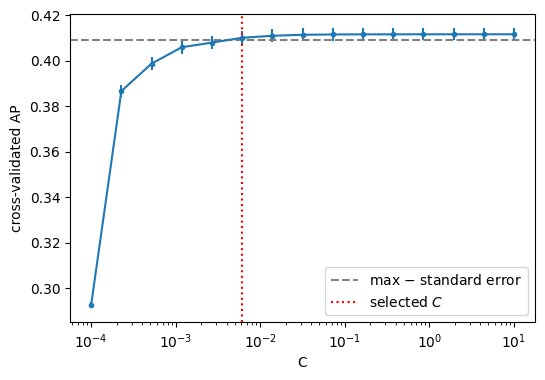

In [13]:
res = grid_l.cv_results_
i_max = res['mean_test_score'].argmax()
threshold = res['mean_test_score'][i_max] - res['std_test_score'][i_max] / np.sqrt(5)
candidates = np.where(res['mean_test_score'] >= threshold)[0]
Cs = res['param_lr__C'].data[candidates].astype(float)
i_1se = candidates[np.argmin(Cs)]
C_1se = float(res['param_lr__C'][i_1se])

print(f"{len(candidates)} models within the noise band")
print(f"C at max : {res['param_lr__C'][i_max]:.5f}  (AP {res['mean_test_score'][i_max]:.4f})")
print(f"C at 1se : {C_1se:.5f}  (AP {res['mean_test_score'][i_1se]:.4f})")

plt.figure(figsize=(6, 4))
C_grid = res['param_lr__C'].data.astype(float)
plt.errorbar(C_grid, res['mean_test_score'],
             yerr=res['std_test_score'] / np.sqrt(5), marker='o', ms=3)
plt.axhline(threshold, ls='--', color='grey', label='max $-$ standard error')
plt.axvline(C_1se, ls=':', color='red', label='selected $C$')
plt.xscale('log'); plt.xlabel('C'); plt.ylabel('cross-validated AP')
plt.legend()
plt.savefig(f'{FIG}/cv_lasso.png', dpi=150, bbox_inches='tight'); plt.show()

In [14]:
path_lasso = f'{ART}/pipe_lasso.pkl'
if os.path.exists(path_lasso):
    pipe_lasso = joblib.load(path_lasso)
else:
    pipe_lasso = Pipeline([
        ('prep', clone(prep)),
        ('lr', LogisticRegression(penalty='l1', solver='saga', max_iter=2000,
                                  tol=1e-4, C=C_1se))
    ])
    pipe_lasso.fit(X_train, y_train)
    joblib.dump(pipe_lasso, path_lasso)

proba_lasso = pipe_lasso.predict_proba(X_test)[:, 1]
coefs_l = pipe_lasso['lr'].coef_[0]

print("columns kept:", (coefs_l != 0).sum(), "out of", len(coefs_l))
print(f"AUC: {roc_auc_score(y_test, proba_lasso):.4f}  (unpenalised {roc_auc_score(y_test, proba_ref):.4f})")
print(f"AP : {average_precision_score(y_test, proba_lasso):.4f}"
      f"  (unpenalised {average_precision_score(y_test, proba_ref):.4f})")

columns kept: 82 out of 125
AUC: 0.7291  (unpenalised 0.7294)
AP : 0.4157  (unpenalised 0.4156)


In [15]:
names_l = pipe_lasso['prep'].get_feature_names_out()
for i in np.argsort(np.abs(coefs_l))[::-1]:
    if coefs_l[i] != 0:
        print(f"{names_l[i]:45s} {coefs_l[i]:+.3f}")

cat__term_ 36 months                          -0.945
num__dti                                      +0.247
cat__purpose_credit_card                      -0.243
cat__term_ 60 months                          +0.191
num__total_il_high_credit_limit               -0.190
num__acc_open_past_24mths                     +0.179
num__loan_amnt                                +0.165
num__mo_sin_old_rev_tl_op                     -0.159
num__total_bal_ex_mort                        +0.148
cat__home_ownership_MORTGAGE                  -0.142
num__total_bc_limit                           -0.140
num__credit_age_months                        +0.115
num__percent_bc_gt_75                         +0.110
cat__home_ownership_RENT                      +0.108
num__missingindicator_emp_length_num          +0.102
cat__verification_status_Not Verified         -0.100
num__total_rev_hi_lim                         -0.097
num__fico_range_low                           -0.094
num__fico_range_high                          

## 9. Saving for the next notebooks

Notebooks 02 and 03 start from these files. Two Colab notebooks don't share memory, so they communicate through saved files, which also means each one can be re-run on its own in a few seconds.

Notebook 03 also needs the loan amounts, which I get through `idx_test` in section 9 bis (this is why I split `df.index` in section 4). These amounts never go into the model.

**A check runs first.** If I re-read the raw file (for example to add a column), the cached models are only valid if the split hasn't changed. The check compares the new lasso probabilities with the saved ones before overwriting them. On a first run there is nothing to compare.

I save here, before sections 10 and 11, because those two are slow and notebook 02 only needs these files. It can run in the meantime.

In [16]:
path_scores = f'{ART}/scores_test.parquet'
if os.path.exists(path_scores):
    old = pd.read_parquet(path_scores)
    assert len(old) == len(proba_lasso), "test set size changed"
    assert np.allclose(old['proba_lasso'].values, proba_lasso), "split or data changed: STOP"
    print("split unchanged, cached models still valid")
else:
    print("first run: nothing to compare")

split unchanged, cached models still valid


In [17]:
pd.DataFrame({'y_test': y_test.values,
              'proba_ref': proba_ref,
              'proba_lasso': proba_lasso},
             index=idx_test).to_parquet(path_scores)
print(sorted(os.listdir(ART)))

['decision_test.parquet', 'df_2015.parquet', 'grid_lasso.pkl', 'lasso_path.parquet', 'lasso_stability.parquet', 'pipe_lasso.pkl', 'pipe_ref.pkl', 'profit_params.json', 'profit_test.parquet', 'scores_test.parquet']


## 9 bis. Profit parameters (training set only)

Notebook 03 decides using a gain if the loan is repaid and a loss if it defaults. Neither is known loan by loan at decision time, so I use averages, estimated here on the training set only and separately for each loan term (which is known at decision time):

- **LGD**: share of the amount lent that is actually lost when a loan defaults, after counting the instalments paid before the default and the recoveries (net of collection fees). This is a loss rate on the amount lent, which is different from the Basel LGD (loss rate on the exposure at default).
- **$\kappa$**: share of the scheduled interest actually received on repaid loans. It is below 1 because many borrowers repay early.

Both are ratios of sums rather than averages of ratios, so a 30,000 USD loan counts three times as much as a 10,000 USD one. This matches a profit measured in dollars.

Censoring affects these parameters too. No 60-month loan from 2015 could reach its end date before the end of 2018, so all the "repaid" 60-month loans in the sample were repaid early, which makes $\kappa_{60}$ much too low. And 60-month defaults are all early defaults, which makes $\mathrm{LGD}_{60}$ too high.

The cell also writes `decision_test.parquet`, with the amounts, Lending Club grades, term, outcome and lasso probability of each test loan. This is the input of notebook 03.

In [18]:
import json

# profit parameters, training set only
tr = df.loc[idx_train].copy()
tr['T'] = tr['term'].str.extract(r'(\d+)')[0].astype(int)
tr['cash'] = tr['total_pymnt'] - tr['collection_recovery_fee']
tr['sched_int'] = tr['installment'] * tr['T'] - tr['funded_amnt']

params = {}
for T, g in tr.groupby('T'):
    dft, paid = g[g['y'] == 1], g[g['y'] == 0]
    params[int(T)] = {
        'LGD':   float(1 - dft['cash'].sum() / dft['funded_amnt'].sum()),
        'kappa': float((paid['cash'] - paid['funded_amnt']).sum() / paid['sched_int'].sum()),
    }
print(params)
with open(f'{ART}/profit_params.json', 'w') as f:
    json.dump(params, f, indent=1)

# test loans and amounts for notebook 03
dec = df.loc[idx_test, COLS_PROFIT + COLS_LC + ['term', 'y']].copy()
dec['proba_lasso'] = proba_lasso
dec.to_parquet(f'{ART}/decision_test.parquet')
print(dec.shape)

{36: {'LGD': 0.38721128898028934, 'kappa': 0.8024427714449447}, 60: {'LGD': 0.47385210411581935, 'kappa': 0.5199025236430233}}
(75029, 14)


### Check: are the parameters the same at every interest rate?

In notebook 03, ranking loans by risk alone did better than the rule that uses dollar amounts. My guess was that $\kappa$ and the LGD are averages per term, while borrowers with a high rate have more reason to refinance (lower $\kappa$) and risky loans default earlier (higher LGD). I check this on the training set, by rate quintile.

Result: $\kappa$ goes down as the rate goes up, for both terms (0.84 to 0.75 for 36 months, 0.61 to 0.47 for 60 months). The LGD increases slightly for 36 months and stays flat for 60 months, where censoring makes every default an early one. With average parameters, the rule overestimates expensive loans, which explains the result of notebook 03. Estimating the parameters by rate band would be the next step. I didn't do it, to keep the decision part simple.

In [19]:
tr['rate_band'] = pd.qcut(tr['int_rate'], 5)
diag = []
for (T, q), g in tr.groupby(['T', 'rate_band'], observed=True):
    dft, paid = g[g['y'] == 1], g[g['y'] == 0]
    diag.append({'term': T, 'rate band': str(q), 'n': len(g),
                 'default rate': g['y'].mean(),
                 'LGD': 1 - dft['cash'].sum() / dft['funded_amnt'].sum(),
                 'kappa': (paid['cash'] - paid['funded_amnt']).sum() / paid['sched_int'].sum()})
pd.DataFrame(diag).set_index(['term', 'rate band']).round(3)

n  default rate    LGD  kappa
term rate band                                        
36   (5.319, 8.18]   65718         0.060  0.370  0.842
     (8.18, 10.99]   46953         0.114  0.365  0.821
     (10.99, 13.18]  47702         0.167  0.383  0.800
     (13.18, 16.49]  40091         0.216  0.388  0.784
     (16.49, 28.99]  25946         0.300  0.415  0.750
60   (5.319, 8.18]    2824         0.132  0.492  0.612
     (8.18, 10.99]    8154         0.195  0.484  0.595
     (10.99, 13.18]  11203         0.272  0.475  0.574
     (13.18, 16.49]  17607         0.347  0.467  0.555
     (16.49, 28.99]  33917         0.464  0.475  0.474

## 10. Regularisation path: what does a shorter scorecard cost?

The one-standard-error rule still keeps most of the columns. This tells me something about the data: the signal is spread over many bureau variables that each add a little, rather than concentrated in a few.

For a scorecard that a credit officer can actually read, the useful question is how much AP is lost with, say, twenty variables. The regularisation path shows the number of non-zero coefficients and the AP for each value of the penalty.

**Fitted on 40,000 loans, which changes the scale of `C`.** scikit-learn minimises $\|w\|_1 + C\sum_i \ell_i$, where the data term is a sum over loans and not a mean. With 40,000 rows instead of 300,000, the same `C` penalises about 7.5 times more. The labels show the equivalent value on the full data, $C \times n_{\text{sub}}/n_{\text{train}}$, so they can be compared with the selected `C`. The x-axis (number of non-zero coefficients) doesn't need any correction, and it's the one that matters.

Result: the AP goes from 0.20 (the base rate) with no variable, to 0.34 with 8 variables and 0.39 with 30, and reaches its plateau (about 0.405) around 50 variables. A 30-variable scorecard would lose about 3 % of AP.

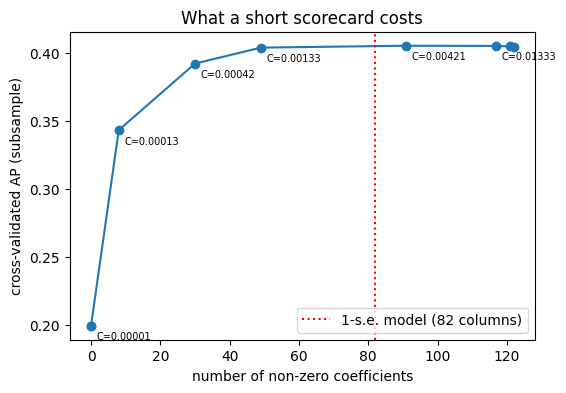

,C,n_nonzero,AP,C_full_equiv
0,0.0001,0,0.1994,0.0000
1,0.0003,0,0.1994,0.0000
2,0.0010,8,0.3432,0.0001
3,0.0032,30,0.3921,0.0004
4,0.0100,49,0.4039,0.0013
5,0.0316,91,0.4053,0.0042
6,0.1000,117,0.4051,0.0133
7,0.3162,121,0.4048,0.0421
8,1.0000,122,0.4047,0.1333


In [20]:
path_lp = f'{ART}/lasso_path.parquet'
if os.path.exists(path_lp):
    lasso_path = pd.read_parquet(path_lp)
else:
    sub = X_train.sample(40_000, random_state=0)
    y_sub = y_train.loc[sub.index]
    rows = []
    for C in np.logspace(-4, 0, 9):
        p = Pipeline([('prep', clone(prep)),
                      ('lr', LogisticRegression(penalty='l1', solver='saga',
                                                max_iter=300, tol=1e-2, C=C))])
        ap = cross_val_score(p, sub, y_sub, cv=3, scoring='average_precision').mean()
        p.fit(sub, y_sub)
        rows.append((C, (p['lr'].coef_[0] != 0).sum(), ap))
        print(f"C={C:.5f}  non-zero={rows[-1][1]:3d}  AP={ap:.4f}")
    lasso_path = pd.DataFrame(rows, columns=['C', 'n_nonzero', 'AP'])
    lasso_path['C_full_equiv'] = lasso_path['C'] * len(sub) / len(X_train)
    lasso_path.to_parquet(path_lp)

n_kept = (pipe_lasso['lr'].coef_[0] != 0).sum()
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(lasso_path['n_nonzero'], lasso_path['AP'], marker='o')
last = -100  # only label points that are far enough apart
for _, r in lasso_path.sort_values('n_nonzero').iterrows():
    if r['n_nonzero'] - last >= 8:
        ax.annotate(f"C={r['C_full_equiv']:.5f}", (r['n_nonzero'], r['AP']), fontsize=7,
                    textcoords='offset points', xytext=(4, -10))
        last = r['n_nonzero']
ax.axvline(n_kept, ls=':', color='red', label=f'1-s.e. model ({n_kept} columns)')
ax.set_xlabel('number of non-zero coefficients')
ax.set_ylabel('cross-validated AP (subsample)')
ax.set_title('What a short scorecard costs'); ax.legend()
fig.savefig(f'{FIG}/lasso_path.png', dpi=150, bbox_inches='tight'); plt.show()
lasso_path.round(4)


## 11. How stable is the lasso selection?

The lasso is good at predicting but not at telling which variables matter. When several variables are correlated, it keeps one more or less at random and sets the others to zero, so the selection depends on the sample. With about fifty correlated bureau variables, some instability is expected. It already shows in the fitted model: `fico_range_low` and `fico_range_high` get exactly the same coefficient, meaning the lasso split the effect between them instead of choosing.

To measure it, I fit a lasso on 20 bootstrap samples of the training set, all with the selected `C` (read from `pipe_lasso` so it matches the saved model), and count how often each column is selected. The samples have the full training size, so `C` means the same thing here, unlike in section 10.

**Counts are matched by column name, not by position.** A rare category (for example a `home_ownership` level that appears only a few times) can be missing from a bootstrap sample. The encoder then produces one column less, and adding the arrays position by position would either crash or shift all the following counts by one.

Slow (20 `saga` fits on 300,000 rows), so it's cached. Notebook 02 can run meanwhile.

Result: about 50 columns are selected in 95 to 100 % of the samples, around twenty in about 80 %, about thirty somewhere between 10 and 70 %, and around fifteen are never selected. This agrees with section 10, where the AP reaches its plateau at about 50 variables.

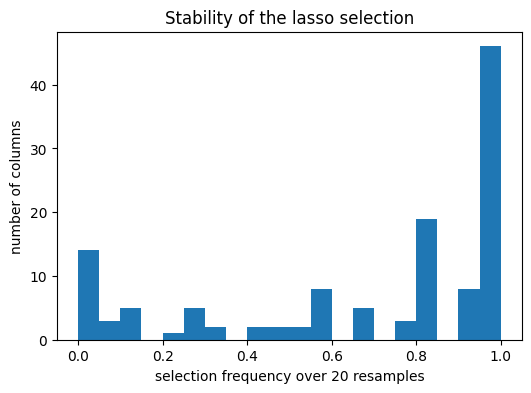

always selected: 46
never selected : 14
in between     : 65


,freq
cat__home_ownership_MORTGAGE,1.0
cat__purpose_debt_consolidation,1.0
cat__purpose_credit_card,1.0
cat__verification_status_Not Verified,1.0
cat__purpose_small_business,1.0
cat__term_ 36 months,1.0
cat__term_ 60 months,1.0
num__acc_open_past_24mths,1.0
num__dti,1.0
num__delinq_2yrs,1.0


In [21]:
path_freq = f'{ART}/lasso_stability.parquet'
if os.path.exists(path_freq):
    freq = pd.read_parquet(path_freq)['freq']
else:
    C_sel = pipe_lasso['lr'].C
    rng = np.random.default_rng(0)
    B = 20
    count = pd.Series(dtype=float)
    for b in range(B):
        ii = rng.choice(len(X_train), size=len(X_train), replace=True)
        pb = Pipeline([('prep', clone(prep)),
                       ('lr', LogisticRegression(penalty='l1', solver='saga',
                                                 max_iter=500, tol=1e-3, C=C_sel))])
        pb.fit(X_train.iloc[ii], y_train.iloc[ii])
        sel = pd.Series(pb['lr'].coef_[0] != 0,
                        index=pb['prep'].get_feature_names_out()).astype(float)
        count = count.add(sel, fill_value=0)
        print(f"bootstrap {b+1}/{B}", end='\r')
    freq = (count / B).rename('freq')
    freq.to_frame().to_parquet(path_freq)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(freq, bins=20)
ax.set_xlabel('selection frequency over 20 resamples')
ax.set_ylabel('number of columns')
ax.set_title('Stability of the lasso selection')
fig.savefig(f'{FIG}/lasso_stability.png', dpi=150, bbox_inches='tight'); plt.show()

print("always selected:", (freq == 1).sum())
print("never selected :", (freq == 0).sum())
print("in between     :", ((freq > 0) & (freq < 1)).sum())
freq.sort_values(ascending=False).head(30)


## Summary

- To find leaks, I asked one question about every column: did it exist at decision time? Removing a column is not always enough, the other columns must not allow rebuilding it (the instalment gives back the rate).
- Missing values carry information here: the indicator holds the signal, the imputed value is a filler.
- Sparsity costs nothing: the lasso keeps 82 of the 125 columns with the same AUC (0.729) and AP (0.416) as the unpenalised model.
- The signal is spread out rather than weak: the regularisation path reaches its plateau at about 50 variables, and about 50 are selected in every bootstrap sample.
- Censoring is measured: the default rate of 60-month loans rises from 34 % to 39 % during 2015, and it also biases the 60-month profit parameters.